In [1]:
import torch
import numpy as np
from PIL import Image
import requests


In [2]:
from transformers import PaliGemmaForConditionalGeneration, PaliGemmaProcessor

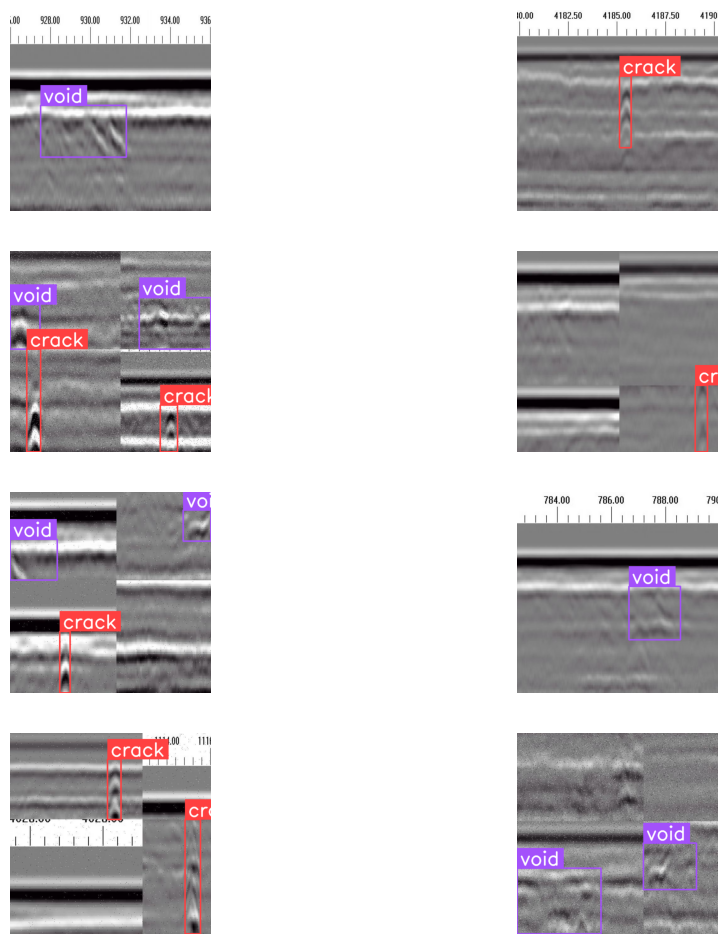

['__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__post_init__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'area', 'box_area', 'class_id', 'confidence', 'data', 'empty', 'from_azure_analyze_image', 'from_deepsparse', 'from_detectron2', 'from_inference', 'from_lmm', 'from_mmdetection', 'from_paddledet', 'from_roboflow', 'from_sam', 'from_tensorflow', 'from_transformers', 'from_ultralytics', 'from_yolo_nas', 'from_yolov5', 'get_anchors_coordinates', 'is_empty', 'mask', 'merge', 'tracker_id', 'with_nmm', 'with_nms', 'xyxy']


In [3]:
####运行程序即可输出图像和目标检测标签#######

import cv2
import json
import supervision as sv
from typing import List

def read_n_lines(file_path: str, n: int) -> List[str]:
    with open(file_path, 'r') as file:
        lines = [next(file).strip() for _ in range(n)]
    return lines

images = []
lines = read_n_lines(f"/root/model/p-1.v1i.paligemma/dataset/_annotations.train1.jsonl", 8)
first = json.loads(lines[0])

CLASSES = first.get('prefix').replace("detect ", "").split(" ; ")

for line in lines:
    data = json.loads(line)
    image = cv2.imread(f"/root/model/p-1.v1i.paligemma/dataset/{data.get('image')}")
    (h, w, _) = image.shape
    detections = sv.Detections.from_lmm(
        lmm='paligemma',
        result=data.get('suffix'),
        resolution_wh=(w, h),
        classes=CLASSES)######在这个sv.Dtections.from_lmm中定义了如何将paligemma的格式坐标转移为图像上的坐标。
    
    image = sv.BoundingBoxAnnotator(thickness=4).annotate(image, detections)
    image = sv.LabelAnnotator(text_scale=2, text_thickness=4).annotate(image, detections)
    images.append(image)

sv.plot_images_grid(images, (4, 2))
print(dir(detections))

In [4]:
############检查环境路径

import os
import sys

# 获取当前工作目录
current_dir = os.getcwd()

# 构建 big_vision_repo 的路径
big_vision_path = os.path.join(current_dir, "big_vision_repo")

# 添加 big_vision_repo 到 PYTHONPATH
os.environ["PYTHONPATH"] = os.environ.get("PYTHONPATH", "") + os.pathsep + big_vision_path

# 确保 Python 知道 big_vision_repo 的位置
sys.path.append(big_vision_path)

# 验证 PYTHONPATH 是否设置成功
print(f"PYTHONPATH is set to: {os.environ['PYTHONPATH']}")

PYTHONPATH is set to: :/root/big_vision_repo


In [5]:
import os

# Step 1: Clone the big_vision repository
if not os.path.exists("big_vision_repo"):
    !git clone --quiet --branch=main --depth=1 https://github.com/google-research/big_vision big_vision_repo

# Step 2: Set the PYTHONPATH environment variable
os.environ['PYTHONPATH'] = os.environ.get('PYTHONPATH', '') + ':' + os.path.abspath("big_vision_repo")

# Verify the PYTHONPATH
print("PYTHONPATH is set to:", os.environ['PYTHONPATH'])#####配置环境路径

PYTHONPATH is set to: :/root/big_vision_repo:/root/big_vision_repo


In [6]:
import os

# Step 1: Clone the big_vision repository
if not os.path.exists("big_vision_repo"):
    !git clone --quiet --branch=main --depth=1 https://github.com/google-research/big_vision big_vision_repo

# Step 2: Set the PYTHONPATH environment variable
os.environ['PYTHONPATH'] = os.environ.get('PYTHONPATH', '') + ':' + os.path.abspath("big_vision_repo")

# Verify the PYTHONPATH
print("PYTHONPATH is set to:", os.environ['PYTHONPATH'])#####配置环境路径

PYTHONPATH is set to: :/root/big_vision_repo:/root/big_vision_repo:/root/big_vision_repo


In [7]:
######检查环境是否配置成功

try:
    import big_vision
    print("big_vision module imported successfully")
except ImportError as e:
    print(f"Error importing big_vision: {e}")

big_vision module imported successfully


In [ ]:
# 设置本地文件路径
#MODEL_PATH = "/root/model/paligemma-3b-pt-224.f16.npz"######官网模型
MODEL_PATH = "/root/autodl-tmp/model-out-8/fine-tuned-paligemma-3b-pt-224.f16.npz"####自己训练好的目标检测模型最优权重
TOKENIZER_PATH = "/root/model/paligemma_tokenizer.model"
dataset_location_for_object_detect = "/root/model/p-1.v1i.paligemma"
dataset_location_for_multimodal = "/root/model/p-1.v1i.paligemma-multimodal/dataset"
#dataset_location = "E://ybx_GPR_test_paligemma//GPR.v3-b-scans-without-noise.paligemma"
# 加载模型示例######定义一个函数用来加载模型，这个模型的路径是在D盘中的可以后续更改，使用NUmP加载模型
def load_model(model_path):
    print(f"Loading model from {model_path}...")
    model = np.load(model_path)  # 使用 NumPy 加载模型
    return model

# 加载标记器示例######加载模型的标记器这个标记器就是用来处理paligemma的文本数据，将这个文本转换为模型可以理解的数字来表示让模型能够读取文字。
def load_tokenizer(tokenizer_path):######################在加载模型的时候一定要注意模型可以直接加载但是对于tokenizer需要转置为二进制再去读取模型的参数，
    print(f"Loading tokenizer from {tokenizer_path}...")#######这是英文tokenizer中包含着处理文本和映射的规则这些数据通常需要存储为序列化对象，这些序列格式需要被反序列化才能python使用
    with open(tokenizer_path, 'rb') as f:####以二进制的形式打开文件
        tokenizer = f.read()  # 根据标记器的实际格式调整
    return tokenizer

# 加载模型和标记器
model = load_model(MODEL_PATH)######加载模型，调用刚才的模型加载函数
tokenizer = load_tokenizer(TOKENIZER_PATH)#####加载标记器，调用刚才定义的tokenizer加载函数
print("Model and tokenizer loaded successfully.")#输出模型和标记器加载成功

# 不要限制TF使用GPU或TPU
# tf.config.set_visible_devices([], "GPU")
# tf.config.set_visible_devices([], "TPU")

# 检查是否有GPU可用
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # 设置GPU使用限制为按需增长，而不是预先分配所有的显存
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

backend = jax.lib.xla_bridge.get_backend()
print(f"JAX version:  {jax.__version__}")
print(f"JAX platform: {backend.platform}")
print(f"JAX devices:  {jax.device_count()}")#####输出当前JAX的版本。

# 如果你希望JAX使用GPU，确保CUDA和cuDNN已正确安装并配置
if backend.platform == 'gpu':
    print("JAX is using GPU")
else:
    print("JAX is not using GPU, check your CUDA/cuDNN installation.")#####验证JAX是否可以正确调用GPU如果不能使用GPU 的话就直接使用CPU.

In [ ]:
# Define model###设置一个不可改变的字典变量,,,,llm表是paligemma中的文本模型是lam
model_config = ml_collections.FrozenConfigDict({
    "llm": {"vocab_size": 257_152},########llm表示的是large language model ,257_152是表示paligemma可以处理的文字表示模型的词汇量为257,152。这意味着模型可以识别和处理257,152个不同的单词或字符。
    "img": {"variant": "So400m/14", "pool_type": "none", "scan": True, "dtype_mm": "float16"}
})##################################################variant: 指定视觉模型的变体，这里是"So400m/14"。这表示模型基于So400m模型架构，并使用14个层。pool_type: 指定池化层的类型，这里是"none"。这表示不使用池化层。
############scan: 指定是否扫描图像，这里是True。这表示模型会扫描图像以提取特征。
#################dtype_mm: 指定模型内部计算的数据类型，这里是"float16"。这表示使用半精度浮点数，可以提高模型的计算效率。
model = paligemma.Model(**model_config)####python语句塘，就是将字典里面的对应的key 和value 分别传入到模型中。
tokenizer = sentencepiece.SentencePieceProcessor(TOKENIZER_PATH)
####SentencePiece是Google开发的一种文本处理工具，用于将文本分割为单词或字符等更小的单位，
#####并将其转换为模型可以理解的数字表示。PaliGemma模型使用SentencePiece进行文本处理，因此需要加载SentencePiece的标记器。sentencepiece.SentencePieceProcessor
####是SentencePiece库中的一个类，用于加载和使用标记器。它提供了各种方法来处理文本，例如：将文本转换为数字表示；将数字表示转换为文本；获取词表大小；获取词汇列表

#######加载参数
params = paligemma.load(None, MODEL_PATH, model_config)

# 定义 `decode` 函数以从模型中采样输出。这段代码定义了 decode 函数，用于从 PaliGemma 模型中采样文本输出。
decode_fn = predict_fns.get_all(model)['decode']
decode = functools.partial(decode_fn, devices=jax.devices(), eos_token=tokenizer.eos_id())#####指定解码函数使用的终止标记，这里是标记器中表示结束的标记的ID。

# 将参数移至 GPU 内存
def is_trainable_param(name, param):
    if name.startswith("llm/layers/attn/"):  return True
    if name.startswith("llm/"):              return False
    if name.startswith("img/"):              return False
    raise ValueError(f"Unexpected param name {name}")
##############按照数据维度分片微调模型参数只调整部分参数，大部分参数是冻结的########################
trainable_mask = big_vision.utils.tree_map_with_names(is_trainable_param, params)###这行代码遍历模型参数，并根据 is_trainable_param 函数的结果，创建一个 trainable_mask 标识符。该标识符用来标记哪些参数是可训练的。

mesh = jax.sharding.Mesh(jax.devices(), ("data"))###jax.sharding.Mesh 用于创建分片方案（sharding scheme），jax.devices() 获取可用的 JAX 设备列表。("data") 指定数据分片维度。这表示数据将沿着 "data" 维度进行分片。

data_sharding = jax.sharding.NamedSharding(mesh, jax.sharding.PartitionSpec("data"))#####jax.sharding.NamedSharding是基于mesh分片方案创建命名分片，然后按照data的维度进行划分。

params_sharding = big_vision.sharding.infer_sharding(params, strategy=[('.*', 'fsdp(axis="data")')], mesh=mesh)####按照完全分片的方式进行分片，并且沿着data维度进行划分。

warnings.filterwarnings("ignore", message="Some donated buffers were not usable")######忽略部分缓冲数据区不能使用的警告

@functools.partial(jax.jit, donate_argnums=(0,), static_argnums=(1,))######就是通过修复原始函数创建新的函数，捐赠的函数参数是由dnoate=0，表示第一个参数不变，不需要微调，，static=1第二个参数需要微调
def maybe_cast_to_f32(params, trainable):######导入参数和可训练的参数
    return jax.tree.map(lambda p, m: p.astype(jnp.float32) if m else p, params, trainable)####tree.map是用来遍历参数的P表示单个参数，m表示需要训练的单个元素。如果是m需要训练的话，参数p就是被强制转化成32为的数据。

params, treedef = jax.tree.flatten(params)
sharding_leaves = jax.tree.leaves(params_sharding)
trainable_leaves = jax.tree.leaves(trainable_mask)#######将params,params_sharding,trainable_mask定义和的参数传入函数。
######就是判断参数是否需要训练,如果需要训练的话就把转为需要训练的float32字符类型,然后再把训练完的参数转为模型最初的形式。
for idx, (sharding, trainable) in enumerate(zip(sharding_leaves, trainable_leaves)):
    params[idx] = big_vision.utils.reshard(params[idx], sharding)
    params[idx] = maybe_cast_to_f32(params[idx], trainable)
    params[idx].block_until_ready()
params = jax.tree.unflatten(treedef, params)#######将训练后的参数还原到模型参数中保持与原来模型参数一致。

def parameter_overview(params):
    for path, arr in big_vision.utils.tree_flatten_with_names(params)[0]:
        print(f"{path:80s} {str(arr.shape):22s} {arr.dtype}")###一个是80个字符，一个是22个字符

print(" == Model params == ")
parameter_overview(params)######遍历打印参数信息。

In [8]:
def preprocess_image(image, size=224):#####定义函数去处理图像
  # Model has been trained to handle images of different aspects ratios
  # resized to 224x224 in the range [-1, 1]. Bilinear and antialias resize
  # options are helpful to improve quality in some tasks.
  image = np.asarray(image)
  if image.ndim == 2:  # Convert image without last channel into greyscale.
    image = np.stack((image,)*3, axis=-1)
  image = image[..., :3]  # Remove alpha layer.
  assert image.shape[-1] == 3

  image = tf.constant(image)
  image = tf.image.resize(image, (size, size), method='bilinear', antialias=True)
  return image.numpy() / 127.5 - 1.0  # [0, 255]->[-1,1]


def preprocess_tokens(prefix, suffix=None, seqlen=None):#####定义处理tokens
  # Model has been trained to handle tokenized text composed of a prefix with
  # full attention and a suffix with causal attention.
  separator = "\n"
  tokens = tokenizer.encode(prefix, add_bos=True) + tokenizer.encode(separator)
  mask_ar = [0] * len(tokens)    # 0 to use full attention for prefix.
  mask_loss = [0] * len(tokens)  # 0 to not use prefix tokens in the loss.

  if suffix:
    suffix = tokenizer.encode(suffix, add_eos=True)
    tokens += suffix
    mask_ar += [1] * len(suffix)    # 1 to use causal attention for suffix.
    mask_loss += [1] * len(suffix)  # 1 to use suffix tokens in the loss.

  mask_input = [1] * len(tokens)    # 1 if it's a token, 0 if padding.
  if seqlen:
    padding = [0] * max(0, seqlen - len(tokens))
    tokens = tokens[:seqlen] + padding
    mask_ar = mask_ar[:seqlen] + padding
    mask_loss = mask_loss[:seqlen] + padding
    mask_input = mask_input[:seqlen] + padding

  return jax.tree.map(np.array, (tokens, mask_ar, mask_loss, mask_input))

def postprocess_tokens(tokens):########定义处理token结束的代码
  tokens = tokens.tolist()  # np.array to list[int]
  try:  # Remove tokens at and after EOS if any.
    eos_pos = tokens.index(tokenizer.eos_id())
    tokens = tokens[:eos_pos]
  except ValueError:
    pass
  return tokenizer.decode(tokens)###返回tokens解码器的输出


In [ ]:
##################################这部分代码使用来加载目标检测训练过程中数据的相关代码
SEQLEN = 128
dataset_location_for_object_detect = "/root/model/p-1.v1i.paligemma"
train_dataset_for_object_detect = big_vision.datasets.jsonl.DataSource(
    os.path.join(dataset_location_for_object_detect, "dataset/_annotations.train1.jsonl"),
    fopen_keys={"image": f"{dataset_location_for_object_detect}/dataset"})
    #fopen_keys={"image": dataset_location })

val_dataset_for_object_detect = big_vision.datasets.jsonl.DataSource(
    os.path.join(dataset_location_for_object_detect, "dataset/_annotations.valid1.jsonl"),
    fopen_keys={"image": f"{dataset_location_for_object_detect}/dataset"})

def train_data_iterator_for_object_detect():#####目标检测训练数据
  """Never ending iterator over training examples."""
  # Shuffle examples and repeat so one can train for many epochs.
  dataset_for_object_detect = train_dataset_for_object_detect.get_tfdata().shuffle(1_000).repeat()
  for example in dataset_for_object_detect.as_numpy_iterator():
    image = Image.open(io.BytesIO(example["image"]))
    image = preprocess_image(image)

    prefix = example["prefix"].decode().lower()
    suffix = example["suffix"].decode().lower()
    tokens, mask_ar, mask_loss, _ = preprocess_tokens(prefix, suffix, SEQLEN)
    label, _, _, _ = preprocess_tokens(suffix, seqlen=SEQLEN)

    yield {
        "image": np.asarray(image),
        "text": np.asarray(tokens),
        "label": np.asarray(label),
        "mask_ar": np.asarray(mask_ar),
        "mask_loss": np.asarray(mask_loss),
    }

def validation_data_iterator_valued_for_object_detect():############在训练目标检测过程，每一轮验证模型权重在验证集上的结果。
  """Single iterator over validation examples."""
  for example in val_dataset_for_object_detect.get_tfdata(ordered=True).as_numpy_iterator():
    image = Image.open(io.BytesIO(example["image"]))
    image = preprocess_image(image)

    prefix = example["prefix"].decode().lower()
    suffix = example["suffix"].decode().lower()
    tokens, mask_ar, _, mask_input = preprocess_tokens(prefix, seqlen=SEQLEN)
    label, _, _, _ = preprocess_tokens(suffix, seqlen=SEQLEN)

    yield {
        "image": np.asarray(image),
        "text": np.asarray(tokens),
        "label": np.asarray(label),
        "mask_ar": np.asarray(mask_ar),
        "mask_input": np.asarray(mask_input),
    }
def validation_data_iterator_trained_for_object_detect():################在训练目标检测过程中，每一轮模型权重在训练集上的结果，之所以加这个定义块，是为了监督模型，防止模型权重过拟合。
  """Single iterator over validation examples."""
  for example in train_dataset.get_tfdata(ordered=True).as_numpy_iterator():
    image = Image.open(io.BytesIO(example["image"]))
    image = preprocess_image(image)

    prefix = example["prefix"].decode().lower()
    suffix = example["suffix"].decode().lower()
    tokens, mask_ar, _, mask_input = preprocess_tokens(prefix, seqlen=SEQLEN)
    label, _, _, _ = preprocess_tokens(suffix, seqlen=SEQLEN)

    yield {
        "image": np.asarray(image),
        "text": np.asarray(tokens),
        "label": np.asarray(label),
        "mask_ar": np.asarray(mask_ar),
        "mask_input": np.asarray(mask_input),
    }


In [ ]:
##################################这部分代码使用来加载多模态训练过程中数据的相关代码
# @title Function to iterate over train and validation examples.
SEQLEN = 128
dataset_location_for_multimodal = "/root/model/p-1.v1i.paligemma-multimodal/dataset"
# TODO: Consider data iterators skipping big_vision and tf.data?
train_dataset_for_multimodal = big_vision.datasets.jsonl.DataSource(
    os.path.join(dataset_location_for_multimodal, "_annotations.train2.jsonl"),
    fopen_keys={"image": dataset_location_for_multimodal})

val_dataset_for_multimodal = big_vision.datasets.jsonl.DataSource(
    os.path.join(dataset_location_for__multimodal, "_annotations.valid2.jsonl"),
    fopen_keys={"image": dataset_location_for_multimodal})


def train_data_iterator_for_multimodal():
  """Never ending iterator over training examples."""
  # Shuffle examples and repeat so one can train for many epochs.
  dataset_for_multimodal = train_dataset_for_multimodal.get_tfdata().shuffle(1_000).repeat()
  for example in dataset.as_numpy_iterator():
    image = Image.open(io.BytesIO(example["image"]))
    image = preprocess_image(image)

    prefix = "caption en"  # Could also be a different prefix per example.
    suffix = example["suffix"].decode().lower()
    tokens, mask_ar, mask_loss, _ = preprocess_tokens(prefix, suffix, SEQLEN)

    yield {
        "image": np.asarray(image),
        "text": np.asarray(tokens),
        "mask_ar": np.asarray(mask_ar),
        "mask_loss": np.asarray(mask_loss),
    }


def validation_data_iterator_for_multimodal():
  """Single iterator over validation examples."""
  for example in val_dataset_for_multimodal.get_tfdata(ordered=True).as_numpy_iterator():
    image = Image.open(io.BytesIO(example["image"]))
    image = preprocess_image(image)

    prefix = "caption en"  # Could also be a different prefix per example.
    tokens, mask_ar, _, mask_input = preprocess_tokens(prefix, seqlen=SEQLEN)

    yield {
        "image": np.asarray(image),
        "text": np.asarray(tokens),
        "mask_ar": np.asarray(mask_ar),
        "mask_input": np.asarray(mask_input),
    }







In [ ]:
def read_n_lines(file_path: str, n: int) -> List[str]: #########only_for_object_detect
    lines = []
    with open(file_path, 'r') as file:
        for _ in range(n):
            line = file.readline()
            if not line:
                break
            lines.append(line.strip())
    return lines




def split_and_keep_second_part(s):  #########only_for_object_detect
    parts = s.split('\n', 1)
    if len(parts) > 1:
        return parts[1]
    return s

def render_inline(image, resize=(128, 128)):  #########for_object_detect and for_multimodal
    """Convert image into inline html."""
    image = Image.fromarray(image)
    image.resize(resize)
    with io.BytesIO() as buffer:
        image.save(buffer, format='jpeg')
        image_b64 = str(base64.b64encode(buffer.getvalue()), "utf-8")
        return f"data:image/jpeg;base64,{image_b64}"
######不加confidence####

def render_example_for_object_detect(image, caption):#########for object_detect
    image = ((image + 1)/2 * 255).astype(np.uint8)  # [-1,1] -> [0, 255]
    h, w, _ = image.shape
    try:
        detections = sv.Detections.from_lmm(
            lmm='paligemma',
            result=caption,
            resolution_wh=(w, h),
            classes=CLASSES)
        image = sv.BoundingBoxAnnotator().annotate(image, detections)
        image = sv.LabelAnnotator().annotate(image, detections)
    except:
        print(caption)
    return f"""
<div style="display: inline-flex; align-items: center; justify-content: center;">
    <img style="width:128px; height:128px;" src="{render_inline(image, resize=(64,64))}" />
    <p style="width:256px; margin:10px; font-size:small;">{html.escape(caption)}</p>
</div>
"""

html_out = ""
for idx, example in zip(range(20), train_data_iterator_for_object_detect()):
    caption = postprocess_tokens(example["text"])  # detokenize model input.
    caption = split_and_keep_second_part(caption)
    
    html_out += render_example_for_object_detect(example["image"], caption)

print("Training examples")
display(HTML(html_out))


def render_example_for_multimodal(image, caption):######for multimodal
  image = ((image + 1)/2 * 255).astype(np.uint8)  # [-1,1] -> [0, 255]
  return f"""
    <div style="display: inline-flex; align-items: center; justify-content: center;">
        <img style="width:128px; height:128px;" src="{render_inline(image, resize=(64,64))}" />
        <p style="width:256px; margin:10px; font-size:small;">{html.escape(caption)}</p>
    </div>
    """

html_out = ""
for idx, example in zip(range(8), train_data_iterator_for_multimodal()):
  caption = postprocess_tokens(example["text"])  # detokenize model input.
  caption = caption[len("caption en\n"):]        # strip prefix
  html_out += render_example(example["image"], caption)

print("Training examples")
display(HTML(html_out))




In [ ]:
import jax
import jax.numpy as jnp

@functools.partial(jax.jit, donate_argnums=(0,))
def update_fn_with_joint_loss(params, batch, learning_rate, detection_loss_weight=0.5, captioning_loss_weight=0.5):
    """
    Update function with a joint loss for object detection and image captioning.

    Args:
        params: Model parameters.
        batch: A dictionary containing the batch of data for both tasks.
        learning_rate: Learning rate for SGD.
        detection_loss_weight: Weight for the detection loss in the joint loss.
        captioning_loss_weight: Weight for the captioning loss in the joint loss.

    Returns:
        Updated parameters and total loss.
    """
    imgs, txts, mask_ar = batch["image"], batch["text"], batch["mask_ar"]

    def detection_loss_fn(params):
        # Compute the object detection loss
        detection_logits, _ = model.apply({"params": params}, imgs, train=True)
        detection_targets = batch["detection_targets"]
        detection_mask = batch["detection_mask"]

        # Use the logic from the single-task detection loss
        detection_loss = jnp.mean(
            jnp.sum((detection_logits - detection_targets) ** 2 * detection_mask, axis=-1)
        )
        return detection_loss

    def captioning_loss_fn(params):
        # Compute the image captioning loss
        text_logits, _ = model.apply({"params": params}, imgs, txts[:, :-1], mask_ar[:, :-1], train=True)
        logp = jax.nn.log_softmax(text_logits, axis=-1)

        mask_loss = batch["mask_loss"][:, 1:]
        targets = jax.nn.one_hot(txts[:, 1:], text_logits.shape[-1])

        token_pplx = jnp.sum(logp * targets, axis=-1)  # sum across vocab_size.
        example_loss = -jnp.sum(token_pplx * mask_loss, axis=-1)  # sum across seq_len.
        example_loss /= jnp.clip(jnp.sum(mask_loss, -1), 1)  # weight by num of tokens.

        return jnp.mean(example_loss)

    # Compute both losses
    detection_loss = detection_loss_fn(params)
    captioning_loss = captioning_loss_fn(params)

    # Combine the losses with weights
    total_loss = (
        detection_loss_weight * detection_loss + captioning_loss_weight * captioning_loss
    )

    # Compute gradients for the combined loss
    grads = jax.grad(lambda p: (
        detection_loss_weight * detection_loss_fn(p) + captioning_loss_weight * captioning_loss_fn(p)
    ))(params)

    # Apply gradients to trainable params using SGD
    def apply_grad(param, gradient, trainable):
        if not trainable:
            return param
        return param - learning_rate * gradient

    params = jax.tree_util.tree_map(apply_grad, params, grads, trainable_mask)

    return params, total_loss


In [ ]:
import time
from tqdm import tqdm
import jax
import numpy as np
import big_vision.utils
import matplotlib.pyplot as plt

# Hyperparameters
BATCH_SIZE = 16
TRAIN_EXAMPLES = 170
LEARNING_RATE = 0.01
EPOCHS = 30
TRAIN_STEPS = TRAIN_EXAMPLES // BATCH_SIZE
EVAL_STEPS = TRAIN_STEPS // 4

train_data_it = train_data_iterator()

# Learning rate scheduler
sched_fn = big_vision.utils.create_learning_rate_schedule(
    total_steps=TRAIN_STEPS * EPOCHS, base=LEARNING_RATE,
    decay_type="cosine", warmup_percent=0.10)

# Initialize metrics
train_metrics = {
    "map50": [],
    "map75": [],
    "map50_95": [],
    "caption_loss": []
}
val_metrics = {
    "map50": [],
    "map75": [],
    "map50_95": [],
    "caption_loss": []
}

# Helper function for mAP calculation
def calculate_map(data_iterator, batch_size, classes):
    targets = []
    predictions = []
    for image, label, prediction in make_predictions(data_iterator, batch_size=batch_size):
        h, w, _ = image.shape
        target = sv.Detections.from_lmm(
            lmm='paligemma',
            result=label,
            resolution_wh=(w, h),
            classes=classes)
        targets.append(target)
        prediction = sv.Detections.from_lmm(
            lmm='paligemma',
            result=prediction,
            resolution_wh=(w, h),
            classes=classes)
        prediction.confidence = np.ones(len(prediction))
        predictions.append(prediction)

    mean_average_precision = sv.MeanAveragePrecision.from_detections(
        predictions=predictions,
        targets=targets,
    )

    return mean_average_precision.map50, mean_average_precision.map75, mean_average_precision.map50_95

# Training loop
for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    epoch_loss = 0
    detection_losses = []
    captioning_losses = []
    
    pbar = tqdm(total=TRAIN_STEPS, desc=f"Epoch {epoch}/{EPOCHS}")

    for step in range(1, TRAIN_STEPS + 1):
        # Create batch
        examples = [next(train_data_it) for _ in range(BATCH_SIZE)]
        batch = jax.tree_map(lambda *x: np.stack(x), *examples)
        batch = big_vision.utils.reshard(batch, data_sharding)

        # Learning rate
        learning_rate = sched_fn(step)

        # Update step
        params, loss = update_fn_with_joint_loss(params, batch, learning_rate)
        loss = jax.device_get(loss)

        # Split detection and captioning losses
        detection_loss = jax.device_get(detection_loss_fn(params))
        captioning_loss = jax.device_get(captioning_loss_fn(params))

        detection_losses.append(detection_loss)
        captioning_losses.append(captioning_loss)

        epoch_loss += loss
        pbar.set_postfix({"Loss": loss, "Learning Rate": learning_rate})
        pbar.update(1)

    pbar.close()
    epoch_loss /= TRAIN_STEPS
    detection_loss_avg = np.mean(detection_losses)
    captioning_loss_avg = np.mean(captioning_losses)

    print(f"Epoch {epoch}/{EPOCHS} - Loss: {epoch_loss:.4f}, Detection Loss: {detection_loss_avg:.4f}, Captioning Loss: {captioning_loss_avg:.4f}")

    # Evaluate every few epochs
    if epoch % 3 == 0 or epoch == EPOCHS:
        map50, map75, map50_95 = calculate_map(validation_data_iterator_valued_for_object_detect(), batch_size=8, classes=CLASSES)
        train_metrics["map50"].append(map50)
        train_metrics["map75"].append(map75)
        train_metrics["map50_95"].append(map50_95)

        print(f"Epoch {epoch}/{EPOCHS} - mAP@50: {map50:.2f}, mAP@75: {map75:.2f}, mAP@50-95: {map50_95:.2f}")

    # Save the best model
    if epoch == EPOCHS:
        with open("/root/autodl-tmp/model-out/joint_model_final.npz", "wb") as f:
            flat, _ = big_vision.utils.tree_flatten_with_names(params)
            np.savez(f, **{k: v for k, v in flat})

    # Save metrics
    train_metrics["caption_loss"].append(captioning_loss_avg)

# Plot training losses
plt.plot(range(1, EPOCHS + 1), train_metrics["caption_loss"], label="Captioning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss for Captioning Task")
plt.legend()
plt.show()

plt.plot(range(1, EPOCHS + 1), train_metrics["map50"], label="mAP@50")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Training mAP@50")
plt.legend()
plt.show()
